In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

states = pd.read_csv("../sources/state_competitiveness.csv")

states.head()

,State,Electricity_Price_cents_per_kWh,Grid_Capacity_MW,Renewable_Share_Percent,Carbon_Intensity_kgCO2_per_kWh,Power_Reliability_Score,Transmission_Congestion_Score,Land_Availability_Score,Water_Stress_Score,Existing_Data_Center_Ecosystem_Score,...,Load_Growth_Pressure_Percent,Power_Delivery_Risk_Score,Natural_Gas_Price_USD_per_MMBtu,Solar_Resource_Score,Geothermal_Potential_Score,Nuclear_Capacity_MW,Behind_The_Meter_Potential_Score,Regional_Competitiveness_Score,Interconnection_Region,Interconnection_Friction_Score
0,Texas,9.79,168317,14.7,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ERCOT,1.00
1,Virginia,10.62,29147,6.5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PJM,0.55
2,Arizona,12.74,32877,7.1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Western Interconnection,0.75
3,California,27.04,96773,34.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CAISO,0.20
4,Nevada,11.47,16725,22.3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Western Interconnection,0.75


In [2]:
print(states.columns)

Index(['State', 'Electricity_Price_cents_per_kWh', 'Grid_Capacity_MW',
       'Renewable_Share_Percent', 'Carbon_Intensity_kgCO2_per_kWh',
       'Power_Reliability_Score', 'Transmission_Congestion_Score',
       'Land_Availability_Score', 'Water_Stress_Score',
       'Existing_Data_Center_Ecosystem_Score',
       'Interconnection_Queue_Time_Years',
       'Available_Transmission_Capacity_MW', 'Substation_Availability_Score',
       'Load_Growth_Pressure_Percent', 'Power_Delivery_Risk_Score',
       'Natural_Gas_Price_USD_per_MMBtu', 'Solar_Resource_Score',
       'Geothermal_Potential_Score', 'Nuclear_Capacity_MW',
       'Behind_The_Meter_Potential_Score', 'Regional_Competitiveness_Score',
       'Interconnection_Region', 'Interconnection_Friction_Score'],
      dtype='str')


In [3]:
states["price_score"] = (
    states["Electricity_Price_cents_per_kWh"].max()
    - states["Electricity_Price_cents_per_kWh"]
) / (
    states["Electricity_Price_cents_per_kWh"].max()
    - states["Electricity_Price_cents_per_kWh"].min()
)

#using installed grid capacity for varaible

states["capacity_score"] = (
    states["Grid_Capacity_MW"]
    - states["Grid_Capacity_MW"].min()
) / (
    states["Grid_Capacity_MW"].max()
    - states["Grid_Capacity_MW"].min()
)

states["renewable_score"] = (
    states["Renewable_Share_Percent"]
    - states["Renewable_Share_Percent"].min()
) / (
    states["Renewable_Share_Percent"].max()
    - states["Renewable_Share_Percent"].min()
)

In [4]:
data_center_counts = {
    "Virginia": 609,
    "Texas": 467,
    "California": 287,
    "Georgia": 219,
    "Ohio": 210,
    "Arizona": 156,
    "Washington": 103,
    "North Carolina": 93,
    "Oregon": 125,
    "Nevada": 71,
    "Utah": 43,
    "Pennsylvania": 131,
    "Illinois": 228,
    "Indiana": 122,
    "Tennessee": 61
}

states["data_center_count"] = states["State"].map(data_center_counts)

states["ecosystem_score"] = (
    states["data_center_count"] - states["data_center_count"].min()
) / (
    states["data_center_count"].max() - states["data_center_count"].min()
)

states["interconnection_score"] = states["Interconnection_Friction_Score"]

## Final Competitiveness Model

Interconnection_Friction_Score is an author-constructed 0–1 index based on regional interconnection and transmission-development conditions. Higher values indicate lower relative development friction.

The final five-factor ranking uses normalized price, capacity, renewable, data center ecosystem, and interconnection scores.

In [5]:
states["competitiveness_score"] = (
    0.25 * states["price_score"]
    + 0.25 * states["capacity_score"]
    + 0.20 * states["renewable_score"]
    + 0.20 * states["ecosystem_score"]
    + 0.10 * states["interconnection_score"]
)

ranking = states.sort_values("competitiveness_score", ascending=False)

export_columns = [
    "State",
    "Electricity_Price_cents_per_kWh",
    "Grid_Capacity_MW",
    "Renewable_Share_Percent",
    "Existing_Data_Center_Ecosystem_Score",
    "Interconnection_Region",
    "Interconnection_Friction_Score",
    "data_center_count",
    "price_score",
    "capacity_score",
    "renewable_score",
    "ecosystem_score",
    "interconnection_score",
    "competitiveness_score",
]

ranking_output = ranking[
    [col for col in export_columns if col in ranking.columns]
].copy()

ranking_output


,State,Electricity_Price_cents_per_kWh,Grid_Capacity_MW,Renewable_Share_Percent,Existing_Data_Center_Ecosystem_Score,Interconnection_Region,Interconnection_Friction_Score,data_center_count,price_score,capacity_score,renewable_score,ecosystem_score,interconnection_score,competitiveness_score
0,Texas,9.79,168317,14.7,NaN,ERCOT,1.00,467,1.000000,1.000000,0.280353,0.749117,1.00,0.805894
8,Washington,10.13,30975,47.3,NaN,Western Interconnection,0.75,103,0.980290,0.130967,1.000000,0.106007,0.75,0.574016
1,Virginia,10.62,29147,6.5,NaN,PJM,0.55,609,0.951884,0.119400,0.099338,1.000000,0.55,0.542689
7,Oregon,11.11,17692,42.8,NaN,Western Interconnection,0.75,125,0.923478,0.046919,0.900662,0.144876,0.75,0.526707
14,Illinois,12.21,46279,6.1,NaN,MISO,0.65,228,0.859710,0.227803,0.090508,0.326855,0.65,0.420351
4,Nevada,11.47,16725,22.3,NaN,Western Interconnection,0.75,71,0.902609,0.040800,0.448124,0.049470,0.75,0.410371
5,Georgia,11.40,39746,5.8,NaN,Southeast,0.50,219,0.906667,0.186465,0.083885,0.310954,0.50,0.402251
3,California,27.04,96773,34.0,NaN,CAISO,0.20,287,0.000000,0.547304,0.706402,0.431095,0.20,0.384326
6,Ohio,11.29,30491,2.3,NaN,PJM/MISO,0.60,210,0.913043,0.127904,0.006623,0.295053,0.60,0.380572
2,Arizona,12.74,32877,7.1,NaN,Western Interconnection,0.75,156,0.828986,0.143002,0.112583,0.199647,0.75,0.380443


In [6]:
from pathlib import Path

output_dir = Path("../outputs/tables")
output_dir.mkdir(parents=True, exist_ok=True)

ranking_output.to_csv(
    output_dir / "state_competitiveness_ranking.csv",
    index=False,
)
ranking_output.to_csv(
    output_dir / "state_competitiveness_results.csv",
    index=False,
)


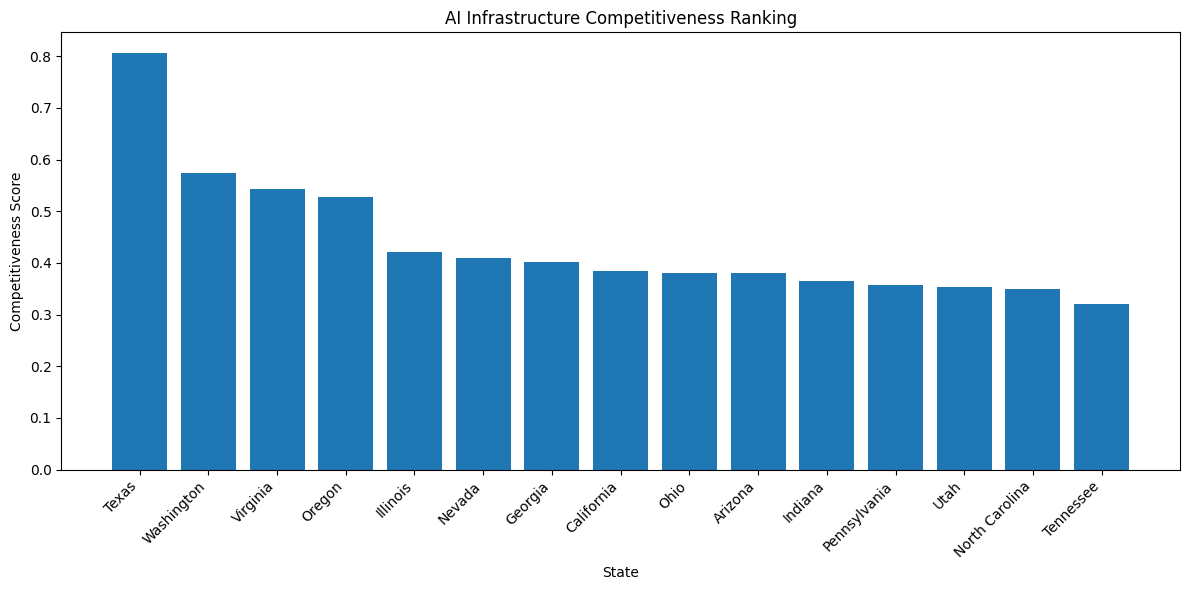

In [7]:
plt.figure(figsize=(12, 6))

plt.bar(
    ranking["State"],
    ranking["competitiveness_score"]
)

plt.title("AI Infrastructure Competitiveness Ranking")
plt.xlabel("State")
plt.ylabel("Competitiveness Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

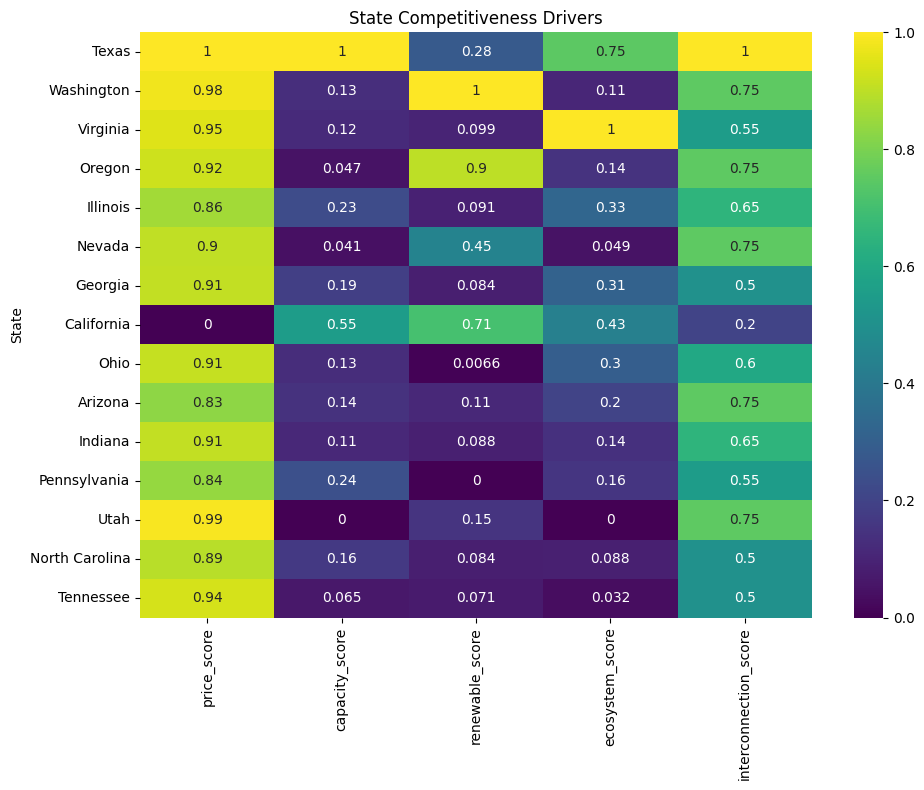

In [8]:
import seaborn as sns

heatmap_data = ranking.set_index("State")[[
    "price_score",
    "capacity_score",
    "renewable_score",
    "ecosystem_score",
    "interconnection_score"
]]

plt.figure(figsize=(10, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="viridis"
)

plt.title("State Competitiveness Drivers")
plt.tight_layout()
plt.show()